## Libraries & Function

In [1]:
%matplotlib ipympl
import numpy as np
from scipy.linalg import expm
from qutip import *
import numba
from numba import njit
import matplotlib.pyplot as plt
from IPython.display import Image, display, Math

In [2]:
#funzione per plottare in LaTex delle matrici
def array_to_latex(array, real = False, array_name = None):
    array = array.real if real else array
    matrix = ''
    for row in array:
        try:
            for number in row:
                matrix += f'{number}&'
        except TypeError:
            matrix += f'{row}&'
        matrix = matrix[:-1] + r'\\'
    if array_name != None:
        display(Math(array_name+r' = \begin{bmatrix}'+matrix+r'\end{bmatrix}'))
    else:
        display(Math(r'\begin{bmatrix}'+matrix+r'\end{bmatrix}'))

### Lindblad functions

In [3]:
def Liouvillian(H, gamma_k, L_k):
    """
    Build the Liouvillian superoperator.
    
    Parameters: - H : ndarray, Hamiltonian matrix
                - gamma_k : list, Decay rates
                - L_k : list, Jump Operators
    
    Returns: - super_L : ndarray, Liouvillian superoperator
    """    
    I = np.eye(H.shape[0])
    super_L = -1.j * (np.kron(I, H) - np.kron(H.T, I))
    
    for k in range(len(gamma_k)):
        super_L += gamma_k[k] * (np.kron(np.conj(L_k[k]), L_k[k]) - 0.5 * np.kron(I, np.conj(L_k[k]).T @ L_k[k]) - 0.5 * np.kron((np.conj(L_k[k]).T @ L_k[k]).T, I))
    
    return super_L


In [4]:
def Lindblad_evo(rho, H, gamma_k, L_k, times, method="expm", vectorized=True):
    """
    Evolution of the density matrix with the Linblad Eq.
    
    Method: - "U" -> propagator = expm(super_L * dt) (needs L_k as NumPy array)
            - "diagonal" -> diagonalizzation of the super-op. (needs L_k as NumPy array )
        
    Vectorized: True/False to choose the output format

    Parameters: - H : Qobj or ndarray, System Hamiltonian
                - rho : Qobj or ndarray, Initial Density Matrix
                - gamma_k : list, List of Decay Rates
                - L_k : list, List of Jump Operators
                - times : array, Time array
        
    Returns : - if vectorized=True → array (N^2, Nt)
              - if vectorized=False → array (Nt, N_site, N_site)
    """
    rho_shape = H.shape[0]
    dt = times[1] - times[0]
   
    # Converts Qobj in NumPy array 
    L_k = [L.full() if hasattr(L, "full") else np.array(L) for L in L_k]
    H = H.full() if hasattr(H, "full") else np.array(H)
    rho = rho.full() if hasattr(rho, "full") else np.array(rho)
        
    # Build up of the Lindbladian
    super_L = Liouvillian(H, gamma_k, L_k)
       
    # Vectorized intial state
    rho_vec = rho.reshape(rho_shape * rho_shape)
        
    # Result array inizialized
    rho_vec_list = np.zeros((rho_shape * rho_shape, len(times)), dtype=complex)
    rho_vec_list[:, 0] = rho_vec

    # -------------
    # Expm method
    # -------------

    # Time Propagator
    if method == "expm":
        super_U = expm(super_L * dt)
            
        # Evolution
        for i in range(1, len(times)):
            rho_vec_list[:, i] = super_U @ rho_vec_list[:, i - 1]
            
        # Output
        if vectorized:
            return rho_vec_list  # (rho_shape^2, Nt)
        else:
            return rho_vec_list.T.reshape(len(times), rho_shape, rho_shape)  # (Nt, rho_shape, rho_shape)

    # ------------------
    # Diagonal method
    # ------------------    
             
    elif method == "diagonal":  
         
        #Diagonalization of the Super-Op.
        W, V = np.linalg.eig(super_L)
        V_inv = np.linalg.inv(V)
                    
        # Build up of the Diagonal Lindbladian
        U_diag = np.exp(W * dt)

        # Initial coefficients in the eigenvectors base
        coeff = V_inv @ rho_vec        
        coeff_list = np.zeros((len(W), len(times)), dtype=complex)
        coeff_list[:, 0] = coeff
           
        # Evolution of the coefficients
        for i in range(1, len(times)):
            coeff_list[:, i] = U_diag * coeff_list[:, i - 1]  

        # Reconversion in the original base
        rho_vec_list = V @ coeff_list
                
        # Output with Eigenenergies & Eigenvectors (as NumPy array)
        if vectorized:
            return rho_vec_list, V, W  
        else:
            return rho_vec_list.T.reshape(len(times), rho_shape, rho_shape), V, W 

    else:
        raise ValueError("Set 'expm', 'diagonal'.")

### Collisional Method functions

In [5]:
def system_Hamiltonian(N_site, E, V_pot, mode="complete"):
    """
    Build up of the System's Hamiltonian for the complete basis (ground & excited states) or only excited states.
    
    Method: - "complete"-> complete basis (ground & excited states)
            - "exc"-> excited basis (only excited states)
    
    Parameters: - E: Float, System's Site Energies (randomly generated)
                - V_pot: Float, Hopping Potential
                - N_site : Int, Number of Sites
        
    Returns : System's Hamiltonian as Numpy array
    """
    # -------------------------
    # Only Excited States Basis
    # -------------------------
    if mode == "exc":   
        H_sys = np.zeros((N_site, N_site), dtype=complex)
        for i in range(N_site):
            H_sys[i, i] = E[i]
        for i in range(N_site):
            for j in range(N_site):
                if i != j:
                    H_sys[i, j] = V_pot
        return H_sys
        
    # --------------
    # Complete Basis 
    # --------------    
    elif mode == "complete":   
        H_sys = np.zeros((2**N_site, 2**N_site), dtype='complex')
        
        for i in range(N_site):
            H_i = (E[i]/2) * (tensor(identity(2**i), identity(2)-sigmaz(), identity(2**(N_site-i-1)))) # g states have 0 energy and the e sites have all the energy
            H_sys += H_i.full()

            for j in range(i+1, N_site):
               H_ij = V_pot/2 * (tensor(identity(2**i), sigmax(), identity(2**(j-i-1)), sigmax(), identity(2**(N_site-j-1))) + tensor(identity(2**i), sigmay(), identity(2**(j-i-1)), sigmay(), identity(2**(N_site-j-1))))
               H_sys += H_ij.full()
        
        return H_sys

    else:
        raise ValueError("mode has to be 'complete' or 'exc'")


In [6]:
def interaction_Hamiltonian_N_ancillas(N_site, c_list):   #Hamiltonian of interaction with N different ancillas, one for every site of the system
    """
    Build up of the Hamiltonian of Interaction for the Collision System - Ancilla
       
    Parameters: - N_site : int, Number of Sites
                - c_list : list, Interaction Forces for the System - Ancilla intercation/collsion
        
    Returns : Hamiltonian of Interaction as Qutip object
    """
    dim_tot = 2**(2 * N_site)
    H_int = np.zeros((dim_tot, dim_tot), dtype=complex)   #inizialization

    for j in range(N_site):
  
        op_list = [identity(2) for _ in range(2 * N_site)]  #list of identity to be fill with the operator sigmaz & sigmax; 2N identity, N for the system and N fo the ancillas
        
        op_list[j] = sigmaz()      # Acts on the j site
        op_list[N_site + j] = sigmax()  # Acts on the j ancilla, with index N + j
        
        H_term = (c_list[j] * tensor(op_list)).full()  # tensor product between the element of the list
        
        H_int += H_term

    return H_int


In [7]:
def hamiltonian_N_ancillas(N_site, E, V_pot, c_list, method="complete"):
    """
    Generation of 3 Hamiltonians for the collision model with N ancillas:
                - H_system : system Hamiltonian
                - H_collision : interaction Hamiltonian with N ancillas
                - H_tot : complete Hamiltonian (system + collision)

    Parameters: - E: Float, System's Site Energies (randomly generated)
                - V_pot: Float, Hopping Potential
                - N_site : int, Number of Sites
                - c_list : list, Interaction Forces for the System - Ancilla intercation/collsion
    
    Method : - "complete"-> complete basis (ground & excited states)
             - "exc"-> excited basis (only excited states)

    Returns : H_system, H_collision, H_tot
    """
    
    if method == "complete":
        
        # ==============
        # Complete Basis 
        # ==============

        H_collision = interaction_Hamiltonian_N_ancillas(N_site, c_list)
    
        H_system = system_Hamiltonian(N_site, E, V_pot, mode="complete")
        
        dim_anc = 2**N_site
        Id_ancillas = np.eye(dim_anc, dtype=complex)
        H_system_expanded = np.kron(H_system, Id_ancillas)  #expand H_sys in the total space
        
        H_tot = H_system_expanded + H_collision
        
        return H_system, H_collision, H_tot
        
    elif method == "excited":        #DA RIVEDERE COME DEFINISCO L'OPERATORE DI COLLSIONE
        # =========================
        # Only Excited States Basis
        # =========================
        
         H_system = Qobj(system_Hamiltonian(N_site, E, V_pot, mode="exc"))
        
         H_collision = 0
         for j in range(N_site):
            diag_vals = np.ones(N_site)
            diag_vals[j] = -1 
            Z_sys_j = Qobj(np.diag(diag_vals))
            
            anc_ops = [identity(2) for _ in range(N_site)]
            anc_ops[j] = sigmax()
            X_anc_j = tensor(anc_ops)
            
            H_collision += c_list[j] * tensor(Z_sys_j, X_anc_j)
        
         Id_ancillas = tensor([identity(2) for _ in range(N_site)])
         H_tot = tensor(H_system, Id_ancillas) + H_collision
        
         return H_system, H_collision, H_tot
        
    else:
         raise ValueError("method has to be 'complete' or 'excited'")

In [8]:
def evolution_operator(H, dt, method='expm', hermitian=True):
    """
    Build up of the evolution operator U = exp(-i H dt) using Expm or analytic diagonalization.
   
    Parameters: - H : Qobj or ndarray, System Hamiltonian
                - dt : float, Timestep
    
    Method : - "expm"-> build up of the Matrix Exponential with expm
             - "diagonalization"->  build up of the propagater U as V @(exp(-i W dt))@ V_dag with W eigenvalues and V eigenvector of the Hamiltonian 

    Returns : Evolution Operator U, 
    """
    H = H.full() if hasattr(H, "full") else np.array(H)
    
    # -----------
    # Expm method
    # -----------
    
    if method == 'expm':
        U = expm(-1j * H * dt)
        return U
        
    # ---------------
    # Diagonalization
    # ---------------
    
    elif method == 'diagonalization':
        if hermitian:
            w, V = np.linalg.eigh(H)
            V_inv = V.conj().T
        else:
            w, V = np.linalg.eig(H) 
            V_inv = np.linalg.inv(V)
                
        U_diag = np.diag(np.exp(-1j * w * dt))
        U = V @ U_diag @ V_inv
        return U, U_diag, w, V

    else:
        raise ValueError("method must be 'expm' or 'diagonalization'")


<h1 style="color:red;">Case of Study : Exciton Dimer</h1> 

#### Evolution with $ U_{complete} $ and then trace on the ancilla

In [9]:
@njit(cache=True)
def _compute_trace_ancilla_core_general(rho_sys, rho_anc, U_step, U_step_dag, 
                                        projectors_np, times, dim_sys, dim_anc, N_site):
    """
    Core computation optimized with Numba - generalized for N sites
    """
    pops_complete = np.zeros((N_site, len(times)), dtype=np.float64)
    
    # Initial state - all sites
    for site in range(N_site):
        pops_complete[site, 0] = np.real(np.trace(projectors_np[site] @ rho_sys))
    
    # Time Evolution
    for t in range(1, len(times)):
        # 1: Expansion
        rho_tot = np.kron(rho_sys, rho_anc)
        
        # 2: Evolution
        rho_tot = U_step @ rho_tot @ U_step_dag
        
        # 3: Partial Trace
        rho_tot_reshaped = rho_tot.reshape(dim_sys, dim_anc, dim_sys, dim_anc)
        
        # Manual trace
        rho_sys = np.zeros((dim_sys, dim_sys), dtype=np.complex128)
        for i in range(dim_sys):
            for j in range(dim_sys):
                for k in range(dim_anc):
                    rho_sys[i, j] += rho_tot_reshaped[i, k, j, k]
        
        # 4: Store populations - all sites
        for site in range(N_site):
            pops_complete[site, t] = np.real(np.trace(projectors_np[site] @ rho_sys))
    
    return pops_complete


def compute_trace_ancilla(rho_sys_initial, rho_anc_all, U_diag, V, times, projectors, N_site):
    """
    Generalized version with Numba optimization for arbitrary number of sites.
    """
    # Convert to numpy
    rho_sys = rho_sys_initial.full() if hasattr(rho_sys_initial, 'full') else rho_sys_initial.copy()
    rho_anc = rho_anc_all.full() if hasattr(rho_anc_all, 'full') else rho_anc_all.copy()
    
    # Convert projectors to numpy array
    projectors_np = np.array([
        P.full() if hasattr(P, 'full') else P 
        for P in projectors ])
    
    # Dimensions
    dim_sys = rho_sys.shape[0]
    dim_anc = rho_anc.shape[0]
    
    # Evolution operator
    V_np = V.full() if hasattr(V, 'full') else V
    U_diag_np = U_diag.full() if hasattr(U_diag, 'full') else U_diag
    U_step = V_np @ U_diag_np @ V_np.conj().T
    U_step_dag = U_step.conj().T
    
    # Call JIT-compiled function
    pops_complete = _compute_trace_ancilla_core_general(
        rho_sys, rho_anc, U_step, U_step_dag, 
        projectors_np, times, dim_sys, dim_anc, N_site )
    
    return pops_complete

#### Single trajectory

In [10]:
@njit(parallel=True, cache=True, fastmath=True)
def _compute_trajectory_wf_core_fast(psi_sys_initial, U_site, Sz_ops, P_10, P_01, 
                                      jump_probabilities, N_traj, N_site, n_times, seed=None):
    """
    Core computation optimized with Numba (JIT compiled)
    """
    if seed is not None:
        np.random.seed(seed)
    
    pop_traj = np.zeros((N_site, n_times, N_traj), dtype=np.float64)
    count = np.zeros(N_traj, dtype=np.float64)
    
    # Precompute initial populations
    P_10_psi = P_10 @ psi_sys_initial
    P_01_psi = P_01 @ psi_sys_initial
    pop_site_1_initial = np.real(np.vdot(psi_sys_initial, P_10_psi))
    pop_site_2_initial = np.real(np.vdot(psi_sys_initial, P_01_psi))
    
    for traj in range(N_traj):
        pop_traj[0, 0, traj] = pop_site_1_initial
        pop_traj[1, 0, traj] = pop_site_2_initial
    
    # Parallel loop over trajectories
    for traj in prange(N_traj):
        psi = psi_sys_initial.copy()
        
        for step in range(1, n_times):
            psi = U_site @ psi
            
            # Monte Carlo jumps
            for site_index in range(N_site):
                if np.random.rand() < jump_probabilities[site_index]:
                    psi = Sz_ops[site_index] @ psi
                    count[traj] += 1
            
            # Compute populations using matrix-vector products
            P_10_psi_t = P_10 @ psi
            P_01_psi_t = P_01 @ psi
            
            pop_traj[0, step, traj] = np.real(np.vdot(psi, P_10_psi_t))
            pop_traj[1, step, traj] = np.real(np.vdot(psi, P_01_psi_t))
    
    return pop_traj, count


def compute_trajectory_wf(dt, c_CM, N_traj, N_site, times, P_10, P_01, psi_sys_initial, U_site):
    """
    Compute quantum trajectory evolution of the wave function with a collisional algorithm.
    Ultra-fast optimized version with Numba JIT compilation and parallelization.
    
    Parameters: - dt : float, Time Step
                - c_CM : array, Collisional model Coefficients
                - N_traj : int, Number of Trajectories
                - N_site : int, Number of Sites
                - times : array, Time array
                - P_10, P_01 : Qobj, Projection Operators on |10> & |01>
                - psi_sys_initial : Qobj, Initial Wave Function
                - U_site : Qobj, Time Evolution Operator
                       
    Returns: - pop_traj : ndarray, Population for each trajectory (N_site x steps x N_traj)
             - average_pop_traj : ndarray, Average population over trajectories (N_site x steps)
             - count : ndarray, Number of collisions per trajectory
    """   
    # Check and conversion to Numpy
    U_site_np = U_site.full() if hasattr(U_site, 'full') else U_site
    psi_sys_initial_np = psi_sys_initial.full() if hasattr(psi_sys_initial, 'full') else psi_sys_initial.copy()
    P_10_np = P_10.full() if hasattr(P_10, 'full') else P_10
    P_01_np = P_01.full() if hasattr(P_01, 'full') else P_01
    
    # Flatten wave function if needed
    if psi_sys_initial_np.ndim > 1:
        psi_sys_initial_np = psi_sys_initial_np.flatten()
    
    # Evolution of the Wave Function
    jump_probabilities = np.array([np.sin(c * dt)**2 for c in c_CM])
    
    # Construction of the sigmaz operator for every site
    Sz_ops = []
    for idx in range(N_site):
        ops = [qeye(2) for _ in range(N_site)]
        ops[idx] = sigmaz()  # Sigmaz only on the index site
        Sz_op = tensor(ops).full()
        Sz_ops.append(Sz_op)
    Sz_ops = np.array(Sz_ops)
    
    # Call JIT-compiled core function (ultra-fast version)
    pop_traj, count = _compute_trajectory_wf_core_fast(
        psi_sys_initial_np, U_site_np, Sz_ops, P_10_np, P_01_np,
        jump_probabilities, N_traj, N_site, len(times), seed=None )
    
    # Average value of different trajectories
    average_pop_traj = np.mean(pop_traj, axis=2)
    
    return pop_traj, average_pop_traj, count

#### Count number of effective collision

In [11]:
@njit(cache=True)
def compute_count_numba(count, steps):
    """
    Normalization of the count of the Inneficient collision over the number of time steps and calculation of the average probability of collsion

    Parameters: - count : array, Number of Inneficient Collision (that applies identity to the system wave function)
                - steps : int, number of Time Steps
    Returns : -count : same matrix Normalized and with number of Effective Collision (that applies sigmaz to the system wave function)
              - media : average probabilty to have an Effective Collision calculated over N trajectories
    """
    count_normalized = count / steps
    media = np.mean(count_normalized)
    return count_normalized, media

count_norm, avg_prob = compute_count_numba(count, steps)


#### Isolated system

In [12]:

# ================
# Isolated system
# ================

def compute_trajectory_wf_isolated(N_site, times, P_10, P_01, psi_sys_initial, U_site):
    """
    Compute quantum trajectory evolution of the wave function with only H_system = Energy of the Site and Hopping Potential V.
    Calculated for only 1 trajecotry (always the same evolution)
    
    Parameters: - N_site : int, Number of Sites
                - steps : int, Number of Time Steps
                - times : array, Time array
                - P_10, P_01 : Qobj, Projection Operators on |10> & |01>
                - psi_sys_initial : Qobj, Initial Wave Function
                - U_site : Qobj, Time Evolution Operator
                       
    Returns: -  pop_traj_isolated : ndarray, Population for each trajectory (N_site x steps x N_traj)
             -  average_pop_traj_isolated : ndarray, Average population over trajectories (N_site x steps)
    """

    # check and conversion in Numpy object
    U_site = U_site.full() if hasattr(U_site, 'full') else U_site
    psi_sys_initial = psi_sys_initial.full() if hasattr(psi_sys_initial, 'full') else psi_sys_initial.copy()
    
    # Isolated system
    pop_traj_isolated = np.zeros((N_site, len(times)))
    
    # Inizialization
    pop_site_1_initial = np.real(np.vdot(psi_sys_initial, P_10 @ psi_sys_initial))
    pop_site_2_initial = np.real(np.vdot(psi_sys_initial, P_01 @ psi_sys_initial))
    
    pop_traj_isolated[0,0] = pop_site_1_initial
    pop_traj_isolated[1,0] = pop_site_2_initial
        
    psi = psi_sys_initial.copy()   #reset initial wf |01>
    
    # Evolution in Time (starting after 1st timestep)
    for step in range(1, len(times)):
            
        psi = U_site @ psi   # Evolution of wf with H_site
                   
        pop_site_1 = np.real(np.vdot(psi, P_10 @ psi))
        pop_site_2 = np.real(np.vdot(psi, P_01 @ psi))
    
        pop_traj_isolated[0, step] = pop_site_1
        pop_traj_isolated [1, step] = pop_site_2
    
    # Average value of different trajectories
    average_pop_isolated = np.mean(pop_traj_isolated, axis=2) 

    return pop_traj_isolated, average_pop_isolated


#### Lindblad

In [13]:
def compute_Lindblad(H_system, rho_sys_initial, gamma_k, L_k, times):
    """
    Compute Lindblad evolution using diagonal method.
    
    Parameters: - H_system : Qobj or ndarray, System Hamiltonian
                - rho_sys_initial : Qobj or ndarray, Initial Density Matrix
                - gamma_k : list, List of Decay Rates
                - L_k : list, List of Jump Operators
                - times : array, Time array
    
    Returns: - rho_list_lindblad : ndarray, Density matrix evolution (len(times) x N_site x N_site)
             - V : ndarray, Eigenvectors of the Liouvillian
             - W : ndarray, Eigenvalues of the Liouvillian
    """
    
    rho_list_lindblad, V, W = Lindblad_evo(rho_sys_initial, H_system, gamma_k, L_k, times, method="diagonal", vectorized=False)

    return rho_list_lindblad, V, W


## Main Loop for varying $ dt $ and $ N_{traj} $

In [14]:
# System's Parameters
N_site = 2            # Number of sites
V_pot = 1.0           # Hopping Potential
E = 1.5 + np.random.randn(N_site)*0.1     #random inizialization of the system energies

# Time Evolution Parameters
dt_list = [0.01, 0.02, 0.05, 0.1 ]     # Time step
tf = 50.0    # Final Time
steps_list = [ int(tf / dt_list[i]) for i in range (len(dt_list)) ]
times_list = [ np.linspace(0, tf, int(steps_list[i])) for i in range(len(dt_list))]

N_traj_list = [100, 1000, 10000]

# Dephasing Parameter (come in MATLAB)
g_deph = 0.1       # Gamma rate

# Scaling for the collsional algorithm c = sqrt(gamma / 4dt)
c_CM_list = np.array([[np.sqrt(g_deph / (4 * dt_list[j])) for j in range(len(dt_list))] for _ in range(N_site)])  # same Coupling for the 2 sites

#Lindblad Rates
gamma_k = [g_deph, g_deph]

#array_to_latex(c_CM)
#array_to_latex(E)

In [15]:
# Initial wave function and density matrix
# System
psi_sys_initial = tensor(basis(2, 0), basis(2, 1)) # I set the population only in site 2
rho_sys_initial = (ket2dm(psi_sys_initial)).full()

# Ancilla
rho_anc_single = ket2dm(basis(2, 0)) # Pure state |0><0| for a singe ancilla
rho_anc_all = (tensor([rho_anc_single for _ in range(N_site)])).full() #for N ancilla

# Projector for the extraction from the rho
P0 = (identity(2) + sigmaz()) / 2  # projector on |0>
P1 = (identity(2) - sigmaz()) / 2  # projector su |1>

P_00 = (tensor(P0, P0)).full() # |00><00|
P_01 = (tensor(P0, P1)).full() # |01><01|
P_10 = (tensor(P1, P0)).full() # |10><10|
P_11 = (tensor(P1, P1)).full() # |11><11|

#Lindblad Jump Operator
L_1 = P_10  # projector on |10><10|
L_2 = P_01  # projector on |01><01|
L_k = [L_1, L_2]

### Calculation

In [16]:
import time   # to evaluate the duration of every calculation

# Dictionary for results
results = {}

print("Starting computation for different dt and N_traj")
print("=" * 60)

# Loop over dt
for dt_idx, dt in enumerate(dt_list):
    
    print(f"Processing dt = {dt:.4f} ({dt_idx+1}/{len(dt_list)})")
    print("-" * 60)
    
    # Extract parameters for this dt
    times = times_list[dt_idx]
    steps = steps_list[dt_idx]
    c_CM = c_CM_list[:, dt_idx]  # Column corresponding to this dt
    
    # ======================================
    # RECALCULATE HAMILTONIANS AND OPERATORS
    # ======================================
    print(f"Recalculating Hamiltonians for dt = {dt:.4f}")       #because c_CM depends on dt
    
    # Hamiltonian & U for Density Matrix (with ancillas)
    H_site, H_coll, H_tot = hamiltonian_N_ancillas(N_site, E, V_pot, c_CM)
    
    U_tot, U_diag, w, V = evolution_operator(H_tot, dt, method='expm', hermitian=True)
    U_tot = Qobj(U_tot, dims=H_tot.dims); U_diag = Qobj(U_diag, dims=H_tot.dims); U_diag_dag = U_diag.dag(); V = Qobj(V, dims=H_tot.dims); V_dag = V.dag() 
    
    # Hamiltonian & U for Wave Function (system only)
    H_system = system_Hamiltonian(N_site, E, V_pot, mode="complete")
    
    U_site, U_diag_site, w_site, V_site = evolution_operator(H_system, dt, method='expm', hermitian=True)
    U_site.dims = H_site.dims
    
    # ====================================
    # LINDBLAD (does not depend on N_traj)
    # ====================================
    print(f"Computing Lindblad")
    start_time = time.time()
    
    rho_list_lindblad, V_lindblad, W_lindblad = compute_Lindblad(H_system, rho_sys_initial, gamma_k, L_k, times)
    
    lindblad_time = time.time() - start_time
    print(f"Completed in {lindblad_time:.2f}s")
    
    # ========================================
    # TRACE ANCILLA (does not depend on N_traj)
    # ========================================
    print(f"Computing Trace Ancilla")
    start_time = time.time()
    
    pops_trace = compute_trace_ancilla(rho_sys_initial, rho_anc_all, U_diag, U_diag_dag, V, V_dag, times, P_10, P_01, N_site)
    
    trace_time = time.time() - start_time
    print(f"Completed in {trace_time:.2f}s")
    
    # Initialize dictionary for this dt
    results[dt] = {}
    
    # ================
    # LOOP OVER N_traj
    # ================
    for N_traj in N_traj_list:
        
        print(f"N_traj = {N_traj}")
        
        # Initialize dictionary for this N_traj
        results[dt][N_traj] = {}
        
        # ------------------------------------
        # TRAJECTORY WF (with collisions)
        # ------------------------------------
        print(f" Computing Trajectory WF")
        start_time = time.time()
        
        pop_traj, average_pop_traj, count = compute_trajectory_wf(dt, c_CM, N_traj, N_site, times, P_10, P_01, psi_sys_initial, U_site)
        
        traj_time = time.time() - start_time
        print(f"Completed in {traj_time:.2f}s")
        
        # Calculate collision statistics
        count_normalized, collision_prob = compute_count(count.copy(), steps)
        
        # ------------------------------------
        # TRAJECTORY ISOLATED (without collisions)
        # ------------------------------------
        print(f" Computing Trajectory Isolated")
        start_time = time.time()
        
        pop_traj_isolated, average_pop_isolated = compute_trajectory_wf_isolated(N_traj, N_site, times, P_10, P_01, psi_sys_initial, U_site)
        
        isolated_time = time.time() - start_time
        print(f"Completed in {isolated_time:.2f}s")
        
        # ==========================
        # SAVE RESULTS IN DICTIONARY
        # ==========================
        results[dt][N_traj] = {
            # Parameters
            'dt': dt,
            'N_traj': N_traj,
            'times': times,
            'steps': steps,
            'c_CM': c_CM,
            
            # Trace Ancilla 
            'trace_ancilla': pops_trace,
            
            # Trajectory WF
            'trajectory_wf': {
                'pop_traj': pop_traj,  # (N_site x len(times) x N_traj)
                'average_pop': average_pop_traj,  # (N_site x len(times))
                'count': count,
                'count_normalized': count_normalized,
                'collision_prob': collision_prob
            },
            
            # Trajectory Isolated
            'trajectory_isolated': {
                'pop_traj': pop_traj_isolated,
                'average_pop': average_pop_isolated
            },
            
            # Lindblad 
            'lindblad': {
                'rho_list': rho_list_lindblad,
                'V': V_lindblad,
                'W': W_lindblad
            },
            
            # Computation times
            'computation_times': {
                'lindblad': lindblad_time,
                'trace_ancilla': trace_time,
                'trajectory_wf': traj_time,
                'trajectory_isolated': isolated_time
            }
        }
        
        print(f" Results saved in results[{dt}][{N_traj}]")

print("\n" + "=" * 60)
print("COMPUTATION COMPLETED!")
print(f" Results saved for:")
print(f"   - {len(dt_list)} dt values: {dt_list}")
print(f"   - {len(N_traj_list)} N_traj values: {N_traj_list}")
print("=" * 60)

Starting computation for different dt and N_traj...
Processing dt = 0.0100 (1/4)
------------------------------------------------------------
Recalculating Hamiltonians for dt = 0.0100
Computing Lindblad
Completed in 0.02s
Computing Trace Ancilla
Completed in 0.76s
N_traj = 100
 Computing Trajectory WF
Completed in 3.46s
 Computing Trajectory Isolated
Completed in 2.70s
 Results saved in results[0.01][100]
N_traj = 1000
 Computing Trajectory WF
Completed in 3694.49s
 Computing Trajectory Isolated
Completed in 39.99s
 Results saved in results[0.01][1000]
N_traj = 10000
 Computing Trajectory WF
Completed in 349.92s
 Computing Trajectory Isolated
Completed in 656.43s
 Results saved in results[0.01][10000]
Processing dt = 0.0200 (2/4)
------------------------------------------------------------
Recalculating Hamiltonians for dt = 0.0200
Computing Lindblad
Completed in 0.01s
Computing Trace Ancilla
Completed in 0.39s
N_traj = 100
 Computing Trajectory WF
Completed in 1.74s
 Computing Trajec

In [17]:
import pickle
import os

# Crea una cartella per i risultati (opzionale)
results_dir = "results"
#os.makedirs(results_dir, exist_ok=True)

# Salva il dizionario
filename = os.path.join(results_dir, "results_NO_Trotter_Suzuki.pkl")

with open(filename, 'wb') as f:
    pickle.dump(results, f)

print(f"✅ Results saved to: {filename}")
print(f"📊 File size: {os.path.getsize(filename) / (1024**2):.2f} MB")

## Plot

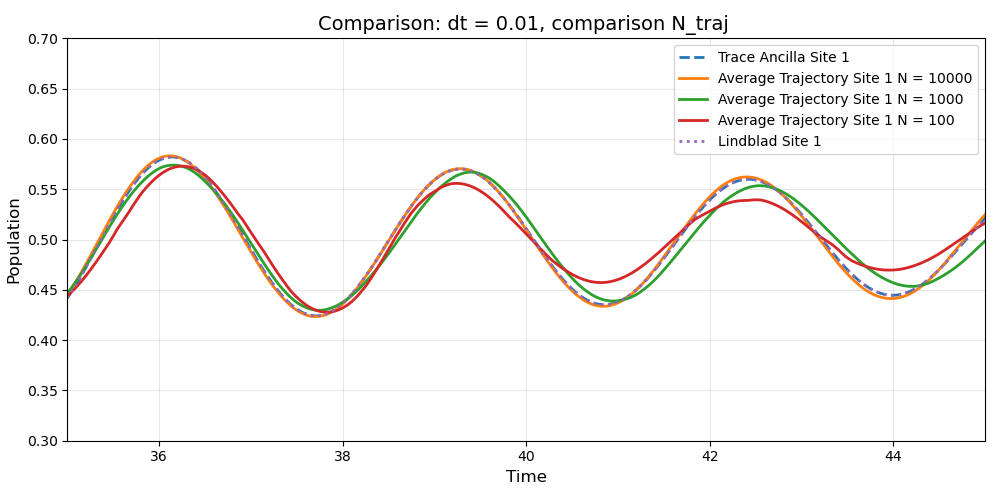

In [18]:
# Scegli quali dt e N_traj vuoi plottare
dt_plot = 0.01  # oppure 0.02, 0.05, 0.1
N_traj_plot_10000 = 10000  # oppure 1000
N_traj_plot_1000 = 1000 
N_traj_plot_100 = 100 

# Estrai i dati dal dizionario
times_plot_10000 = results[dt_plot][N_traj_plot_10000]['times']
trace_pop_10000 = results[dt_plot][N_traj_plot_10000]['trace_ancilla']
average_pop_10000 = results[dt_plot][N_traj_plot_10000]['trajectory_wf']['average_pop']

times_plot_1000 = results[dt_plot][N_traj_plot_1000]['times']
trace_pop_1000 = results[dt_plot][N_traj_plot_1000]['trace_ancilla']
average_pop_1000 = results[dt_plot][N_traj_plot_1000]['trajectory_wf']['average_pop']

times_plot_100 = results[dt_plot][N_traj_plot_100]['times']
trace_pop_100 = results[dt_plot][N_traj_plot_100]['trace_ancilla']
average_pop_100 = results[dt_plot][N_traj_plot_100]['trajectory_wf']['average_pop']

rho_lindblad = results[dt_plot][N_traj_plot_10000]['lindblad']['rho_list']

# Plot per il sito 1 (|10>)
fig01, ax = plt.subplots(figsize=(10, 5))

ax.plot(times_plot_1000, trace_pop_1000[0, :], label=r'Trace Ancilla Site 1', linewidth=2, linestyle='--')
ax.plot(times_plot_10000, average_pop_10000[0, :], label=r'Average Trajectory Site 1 N = 10000', linewidth=2)
ax.plot(times_plot_1000, average_pop_1000[0, :], label=r'Average Trajectory Site 1 N = 1000', linewidth=2)
ax.plot(times_plot_100, average_pop_100[0, :], label=r'Average Trajectory Site 1 N = 100', linewidth=2)
ax.plot(times_plot_10000, np.real(rho_lindblad[:, 2, 2]), label=r'Lindblad Site 1', linewidth=2, linestyle=':')

ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Population', fontsize=12)
ax.set_title(f'Comparison: dt = {dt_plot}, comparison N_traj ', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
ax.set_xlim(35, 45)
ax.set_ylim(0.3, 0.7)
plt.show()

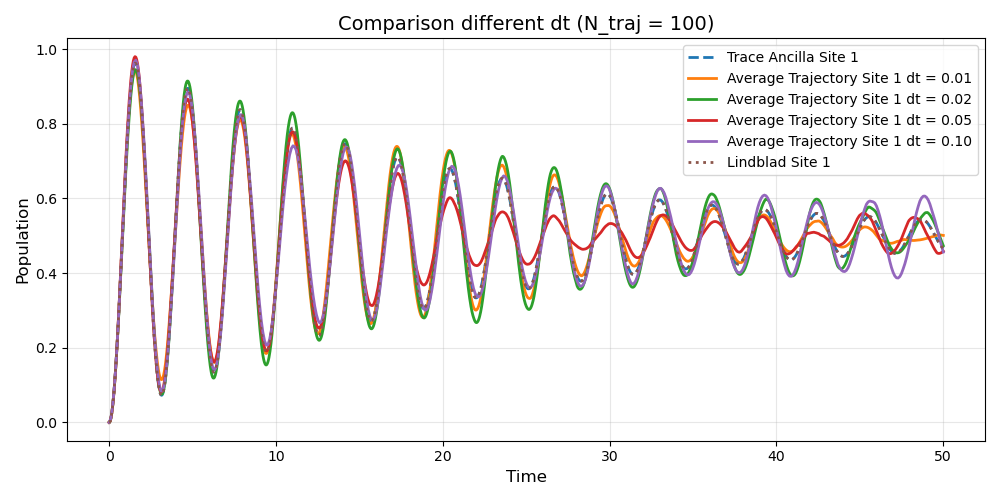

In [19]:
# Plot per il sito 1 (|10>)
fig02, ax = plt.subplots(figsize=(10, 5))

# Trace Ancilla (uguale per tutti i dt, uso 0.01)
ax.plot(results[0.01][100]['times'], results[0.01][100]['trace_ancilla'][0, :], 
        label=r'Trace Ancilla Site 1', linewidth=2, linestyle='--')

# Average trajectories per diversi dt
ax.plot(results[0.01][100]['times'], results[0.01][100]['trajectory_wf']['average_pop'][0, :], 
        label=r'Average Trajectory Site 1 dt = 0.01', linewidth=2)
ax.plot(results[0.02][100]['times'], results[0.02][100]['trajectory_wf']['average_pop'][0, :], 
        label=r'Average Trajectory Site 1 dt = 0.02', linewidth=2)
ax.plot(results[0.05][100]['times'], results[0.05][100]['trajectory_wf']['average_pop'][0, :], 
        label=r'Average Trajectory Site 1 dt = 0.05', linewidth=2)
ax.plot(results[0.10][100]['times'], results[0.10][100]['trajectory_wf']['average_pop'][0, :], 
        label=r'Average Trajectory Site 1 dt = 0.10', linewidth=2)

# Lindblad (uso dt=0.01, uguale per tutti)
ax.plot(results[0.01][100]['times'], np.real(results[0.01][100]['lindblad']['rho_list'][:, 2, 2]), 
        label=r'Lindblad Site 1', linewidth=2, linestyle=':')

ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Population', fontsize=12)
ax.set_title(f'Comparison different dt (N_traj = 100)', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
#ax.set_xlim(35, 45)
#ax.set_ylim(0.3, 0.7)
plt.show()